# 312.1. Accessing and visualizing faint features in coadd images with the Butler

<div style="max-width:300px; float: left; margin-right: 1em">

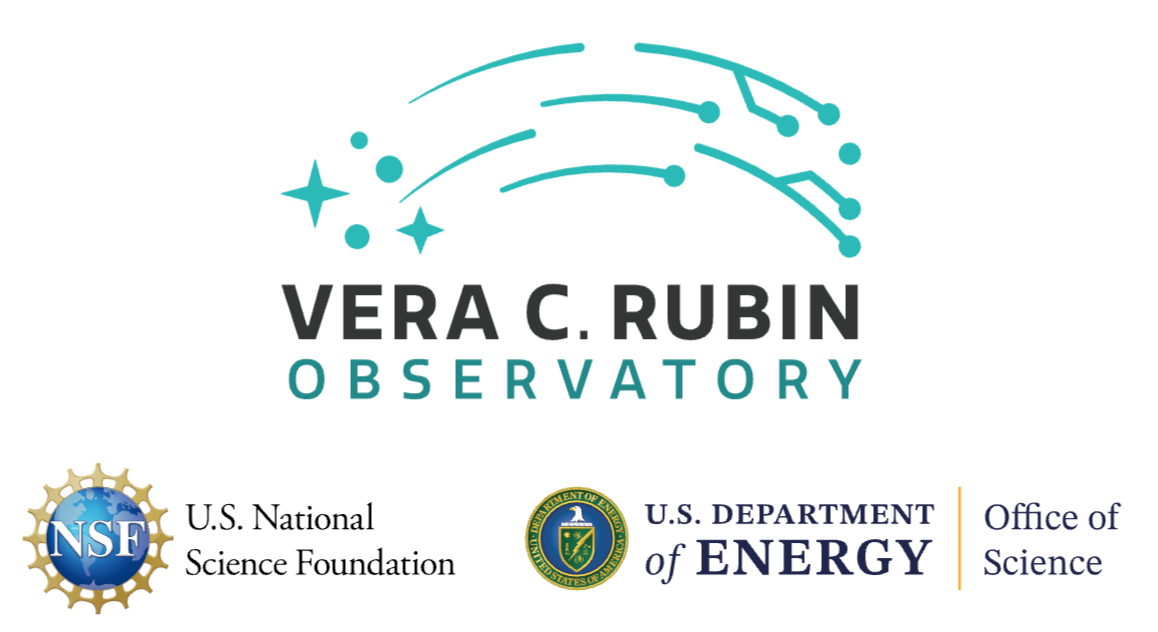

</div>

For the Rubin Science Platform at data.lsst.cloud. \
Data Release: [Data Preview 1](https://dp1.lsst.io/) \
Container Size: large \
LSST Science Pipelines version: r29.2.0 \
Last verified to run: 2026-07-06 \
Repository: [github.com/lsst/tutorial-notebooks](https://github.com/lsst/tutorial-notebooks)

**Learning objective:** Use the Butler to load a `deep_coadd` patch from DP1, display it with a stretch suited to faint extended emission, and understand how the choice of stretch function and display range determines what is visible in the data.

**LSST data products:** `deep_coadd`, `skyMap`

**Packages:** `lsst.daf.butler`, `lsst.geom`, `lsst.afw.display`, `astropy.visualization`

**Credit:** Originally developed by the Rubin Community Science team.
Please consider acknowledging them if this notebook is used for the preparation of journal articles, software releases, or other notebooks.

**Get Support:**
Everyone is encouraged to ask questions or raise issues in the
[Support Category](https://community.lsst.org/c/support/6)
of the Rubin Community Forum.
Rubin staff will respond to all questions posted there.

## 1. Introduction

Low surface brightness (LSB) science depends on detecting faint signals including diffuse galaxy outskirts, tidal debris, and intracluster light. These features can be 100 to 10,000 times fainter than the night sky background. Reaching these depths requires both deep imaging and careful image handling. The first step is knowing how to access and visualize the data at the signal levels where LSB structures live.

This notebook demonstrates how to use the Butler to load a `deep_coadd` patch from the DP1 Extended Chandra Deep Field South (ECDFS) field, display it with a stretch calibrated for faint extended emission, and understand how stretch function and display range choices interact.

**Related tutorials:** Tutorial 103.5 demonstrates interactive image display with Firefly; 103.8 covers image display with matplotlib; 103.9 covers image stamps and bounding-box access. Tutorial 312.2 applies noise-suppression techniques to reveal faint structure; 312.3 covers interactive surface brightness measurement of tidal features.

### 1.1. Import packages

`lsst.daf.butler` provides data access; `lsst.geom` handles sky-coordinate and pixel-geometry operations; `lsst.afw.display` renders images with an astronomically appropriate stretch. Standard scientific Python packages (`numpy`, `matplotlib`, `astropy`) handle array operations, visualization, and coordinate arithmetic.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import AsinhStretch, ImageNormalize, LinearStretch

import lsst.geom as geom
import lsst.afw.display as afwDisplay
from lsst.daf.butler import Butler

### 1.2. Define parameters and functions

Set the display backend and plotting defaults, then define the helper functions used throughout the notebook: `build_sky_arr` masks detected sources and detector artifacts, `sky_stats` estimates the sky level and noise used to set display limits, and `nJy_per_pix_to_mu` converts pixel flux to surface brightness.

In [ ]:
afwDisplay.setDefaultBackend("matplotlib")
plt.rcParams.update(
    {"figure.dpi": 150, "image.origin": "lower", "axes.titlesize": 10})

`build_sky_arr` masks detected sources and detector artifacts (`DETECTED`, `SAT`, `BRIGHT_OBJECT` etc.) by setting those pixels to `NaN`, so that sky statistics are not biased by bright compact objects.

In [ ]:
def build_sky_arr(
    masked_image,
    arr,
    bad_planes=("SAT", "NO_DATA", "BAD", "CR", "BRIGHT_OBJECT"),
    source_planes=("DETECTED",),
):
    """Return arr with artifact and source pixels set to NaN.

    Parameters
    ----------
    masked_image : lsst.afw.image.MaskedImage
        Masked image whose mask plane is used to identify bad pixels.
    arr : ndarray, shape (ny, nx)
        Pixel array to mask, typically the image or variance plane.
    bad_planes : tuple of str, optional
        Mask plane names treated as artifacts.
    source_planes : tuple of str, optional
        Mask plane names treated as detected sources.

    Returns
    -------
    masked_arr : ndarray, shape (ny, nx)
        Copy of arr with artifact, source, and non-finite pixels set to NaN.
    """

    mask_arr = masked_image.getMask().getArray()
    mask_pd = masked_image.getMask().getMaskPlaneDict()
    exclude = np.zeros(arr.shape, dtype=bool)
    for plane in list(bad_planes) + list(source_planes):
        if plane in mask_pd:
            exclude |= (mask_arr & (1 << mask_pd[plane])) != 0
    return np.where(exclude | ~np.isfinite(arr), np.nan, arr)

`sky_stats` estimates the sky level and per-pixel noise, returning display limits `(vmin, vmax)`.

Sky noise is the pixel-to-pixel variation in flux on blank patches of sky, measured after masking detected sources and instrument artifacts. It sets the fundamental detection floor: any structure fainter than a few sky noise units per pixel is invisible without additional noise suppression. Here sky noise is estimated robustly: the sky level is the median of the source-free pixel array, and the noise is $\hat{\sigma} = 1.4826 \times \mathrm{MAD}$, where MAD is the median absolute deviation and the factor 1.4826 makes $\hat{\sigma}$ consistent with the standard deviation of a Gaussian distribution. The display limits are $v_\mathrm{min} = \mathrm{sky} - l \times \hat{\sigma}$ and $v_\mathrm{max} = \mathrm{sky} + h \times \hat{\sigma}$, where $l$ and $h$ are the `lo_sigma` and `hi_sigma` parameters, defaulting to 2 and 8 respectively.

In [ ]:
def sky_stats(arr, lo_sigma=2.0, hi_sigma=8.0):
    """Return (vmin, vmax) anchored to the sky background.

    Uses the robust median as sky level and 1.4826 x MAD as pixel noise.
    Pass a source-masked array (e.g. from build_sky_arr) so that detected
    sources do not bias the estimates.

    Parameters
    ----------
    arr : ndarray
        Pixel array, typically source-masked (NaN at bad/source pixels).
    lo_sigma : float, optional
        Lower stretch limit in units of sky noise below the sky median.
    hi_sigma : float, optional
        Upper stretch limit in units of sky noise above the sky median.

    Returns
    -------
    vmin : float
        Lower display limit (sky - lo_sigma * noise).
    vmax : float
        Upper display limit (sky + hi_sigma * noise).
    sigma : float
        Per-pixel noise estimate (1.4826 * MAD).
    """
    flat = arr[np.isfinite(arr)]
    sky = np.median(flat)
    sigma = 1.4826 * np.median(np.abs(flat - sky))
    return sky - lo_sigma * sigma, sky + hi_sigma * sigma, sigma


`nJy_per_pix_to_mu` converts pixel flux in nJy to AB surface brightness in mag arcsec$^{-2}$, using `PIXEL_AREA`.

`PIXEL_SCALE` and `PIXEL_AREA` are not passed to the function as arguments: they are assigned as global variables in Section 2, immediately after the coadd is loaded. Python looks up a name used inside a function body in the global namespace at the time the function is *called*, not when it is defined, so `nJy_per_pix_to_mu` can be defined here, before `PIXEL_AREA` exists.

In [ ]:
def nJy_per_pix_to_mu(flux_nJy):
    """Convert nJy pixel**-1 to AB mag arcsec**-2 for the LSST pixel scale.

    Parameters
    ----------
    flux_nJy : float or array_like
        Pixel flux in nJy pixel**-1.

    Returns
    -------
        Surface brightness in AB mag arcsec**-2.
    """
    return -2.5 * np.log10(flux_nJy * 1e-9 / PIXEL_AREA / 3631.0)


## 2. Load a coadd patch

Instantiate the Butler with the DP1 repository, locate the tract and patch containing the ECDFS field center, and load the `deep_coadd` for the i-band.

Instantiate the Butler with the DP1 repository and load the `skyMap` for the ECDFS field.

In [ ]:
butler = Butler("dp1", collections="LSSTComCam/DP1")
skymap_name = "lsst_cells_v1"

skymap = butler.get("skyMap", skymap=skymap_name)

Locate the tract and patch containing the target sky coordinate.

In [ ]:
target_ra = 53.218
target_dec = -28.095
band = "i"

sky_point = geom.SpherePoint(
    target_ra * geom.degrees, target_dec * geom.degrees)
tract_info = skymap.findTract(sky_point)
patch_info = tract_info.findPatch(sky_point)
tract_id = tract_info.getId()
patch_id = patch_info.getSequentialIndex()
patch_wcs = tract_info.getWcs()
patch_bbox = patch_info.getOuterBBox()

Construct the `dataId` from the band, tract, and patch, then load the `deep_coadd` and derive the pixel scale from its WCS.

In [ ]:
data_id = {"band": band, "tract": tract_id, "patch": patch_id}
coadd = butler.get("deep_coadd", dataId=data_id)
PIXEL_SCALE = coadd.getWcs().getPixelScale().asArcseconds()
PIXEL_AREA = PIXEL_SCALE**2
print(f"Pixel scale: {PIXEL_SCALE: .4f} arcsec/pixel")
coadd_arr = coadd.image.array.copy()

Mask detected sources and artifacts using `build_sky_arr` and estimate the sky noise from the remaining pixels. Sky noise is the pixel-to-pixel flux variation remaining after the pipeline subtracts the large-scale background; it sets the fundamental detection floor for low-surface-brightness features. Expressing display limits in multiples of the sky noise gives a stretch that is physically motivated and reproducible.

In [ ]:
coadd_sky = build_sky_arr(coadd.getMaskedImage(), coadd_arr)

width_arcmin = coadd_arr.shape[1] * PIXEL_SCALE / 60
height_arcmin = coadd_arr.shape[0] * PIXEL_SCALE / 60
print(f"Shape: {coadd_arr.shape}  ({width_arcmin: .1f} x {height_arcmin: .1f} arcmin)")

n_sky = np.isfinite(coadd_sky).sum()
n_tot = coadd_sky.size
print(
    f"Sky pixels for statistics: {format(n_sky, ',')} / {format(n_tot, ',')}"
    f"  ({100 * np.isfinite(coadd_sky).mean(): .1f}%)"
)
sky_val = np.nanmedian(coadd_sky)
print(f"Sky level: {sky_val: .1f} nJy/pix = {nJy_per_pix_to_mu(sky_val): .1f} mag/arcsec^2")
_, _, sky_sigma = sky_stats(coadd_sky)
mu_sigma = nJy_per_pix_to_mu(sky_sigma)
print(f"Per-pixel 1-sigma noise: {sky_sigma: .1f} nJy/pix = {mu_sigma: .1f} mag/arcsec^2")

## 3. Image display

Two display approaches are used in this notebook.

`lsst.afw.display` is the Science Pipelines library for image display. It supports a Firefly backend (the RSP's interactive viewer, covered in tutorial 103.5) and a matplotlib backend (tutorial 103.8). This notebook uses the matplotlib backend. Its `scale()` method takes a stretch name and a display range:

```python
disp.scale('asinh', 'zscale')           # ZScale: automatic range
disp.scale('asinh', min=vmin, max=vmax)  # explicit range from sky_stats()
```

*ZScale* fits a linear function to the core of the pixel histogram to set the display range automatically. The range adapts to each image so the same surface brightness will appear at a different gray level in images of different depth or background. Setting `min`/`max` explicitly from `sky_stats()` anchors the display to the physical noise floor. This approach is used in section 3.1.

`ImageNormalize` (astropy) and `imshow` (matplotlib) are used for the comparison grids in sections 3.2.1. and 3.2.2. `lsst.afw.display` interprets its `min`/`max` arguments differently for different stretches — for asinh it uses the Lupton et al. (2004) parameterization in which the arguments control the softening, not the black and white points. `ImageNormalize` always treats `vmin` and `vmax` as pixel flux cutoffs, which is helpful for a controlled comparison.

### 3.1. Full-patch display

Display the full coadd patch with a sky-noise anchored stretch.

In [ ]:
vmin, vmax, _ = sky_stats(coadd_sky)
fig = plt.figure(figsize=(4, 4))
disp = afwDisplay.Display(frame=fig)
disp.scale("asinh", min=vmin, max=vmax)
disp.image(coadd.image)
plt.show()

> Figure 1: The full i-band deep_coadd patch displayed with an arcsinh stretch anchored to the sky noise floor. The display range runs from sky $- 2\hat{\sigma}$ (black) to sky $+ 8\hat{\sigma}$ (white).

### 3.2. Postage stamp and stretch comparison

Define the four coordinates used as demonstration targets throughout sections 4.1 and 4.2.

In [ ]:
demo_targets = [
    (53.3375, -27.810),
    (53.010, -28.350),
    (52.965, -28.184),
    (53.220, -28.095),
]

Load a 4′ × 4′ stamp centered on each target galaxy. The third stamp may appear smaller or off-center because the requested bounding box extends beyond the patch boundary and is clipped; `bbox.clip()` handles this silently.

In [ ]:
half_width = 600

demo_stamps = []
for ra, dec in demo_targets:
    sp = geom.SpherePoint(ra * geom.degrees, dec * geom.degrees)
    ti = skymap.findTract(sp)
    pi = ti.findPatch(sp)
    wcs = ti.getWcs()
    cen = wcs.skyToPixel(sp)
    did = {"band": band, "tract": ti.getId(), "patch": pi.getSequentialIndex()}
    bbox = geom.Box2I(
        geom.Point2I(int(cen.getX()) - half_width,
                     int(cen.getY()) - half_width),
        geom.Extent2I(2 * half_width, 2 * half_width),
    )
    bbox.clip(pi.getOuterBBox())
    stamp = butler.get("deep_coadd", dataId=did, parameters={"bbox": bbox})
    sky_a = build_sky_arr(stamp.getMaskedImage(), stamp.image.array)
    demo_stamps.append((sky_a, stamp, f"RA={ra}  Dec={dec}"))

stamp_arcmin = 2 * half_width * PIXEL_SCALE / 60
fig, axes = plt.subplots(4, 1, figsize=(4, 4 * 4), squeeze=False)
for idx, (sky_a, stamp, label) in enumerate(demo_stamps):
    plt.sca(axes[idx][0])
    disp = afwDisplay.Display(frame=fig)
    vmin, vmax, _ = sky_stats(sky_a)
    disp.scale("asinh", min=vmin, max=vmax)
    disp.image(stamp.image)
    axes[idx][0].set_title(label, fontsize=8)

> Figure 2: Four 4-arcminute by 4-arcminute i-band postage stamps centered on target galaxies in the ECDFS field, loaded via bounding-box sub-region access. Each stamp is independently scaled to its local sky noise using an arcsinh stretch. The third stamp is smaller because its bounding box was clipped to the patch boundary.

#### 3.2.1. Stretch functions

Every image display maps pixel flux values onto a $[0,\,1]$ grey-scale range. Let $t = (x - v_\mathrm{min})\,/\,(v_\mathrm{max} - v_\mathrm{min})$ be the normalized pixel value. The two transfer functions used here are:

| Stretch | Transfer function | Behavior |
|---------|-------------------|-----------|
| **Linear** | $f(t) = t$ | Uniform mapping; preserves noise texture near sky level but saturates bright sources unless $v_\mathrm{max}$ is set conservatively |
| **Arcsinh** | $f(t) = \mathrm{arcsinh}(t/a)\,/\,\mathrm{arcsinh}(1/a)$ | Near-linear at small $t$, logarithmic at large $t$; allocates more of the grey-scale range to faint emission while keeping bright sources visible |

The `a` parameter in `AsinhStretch` controls how quickly the function transitions from near-linear to logarithmic behavior. Smaller values devote more grey-scale contrast to faint structure; larger values approach linear. `AsinhStretch(a=0.1)` is the default (as used by `afwDisplay` internally). Changing it is straightforward:

```python
AsinhStretch(a=0.1)   # default — greatest contrast in the faint regime
AsinhStretch(a=0.5)   # gentler — brighter features retain more structure
AsinhStretch(a=2.0)   # close to linear
```

Both panels below use the same display range (sky $-$ $2\hat{\sigma}$ to sky $+$ $30\hat{\sigma}$) so that any visual difference is due solely to the transfer function.

In [ ]:
stretches = [
    ("Linear", LinearStretch(), 30),
    ("Asinh", AsinhStretch(a=0.05), 30),
]

lo = 2.0
fig, axes = plt.subplots(
    len(demo_stamps),
    2,
    figsize=(6, 2 * len(demo_stamps)),
    squeeze=False,
)
for row, (sky_a, stamp, gal_label) in enumerate(demo_stamps):
    flat = sky_a[np.isfinite(sky_a)]
    sky = np.median(flat)
    sigma = 1.4826 * np.median(np.abs(flat - sky))
    bbox = stamp.getBBox()
    stamp_extent = (bbox.beginX, bbox.endX, bbox.beginY, bbox.endY)
    for col, (name, stretch_fn, hi) in enumerate(stretches):
        norm = ImageNormalize(
            vmin=sky - lo * sigma,
            vmax=sky + hi * sigma,
            stretch=stretch_fn,
        )
        axes[row][col].imshow(
            stamp.image.array,
            norm=norm,
            cmap="Greys_r",
            origin="lower",
            extent=stamp_extent,
        )
        if row == 0:
            axes[row][col].set_title(
                f"{name}  (-{int(lo)}$\\hat{{\\sigma}}$ to +{hi}$\\hat{{\\sigma}}$)")
        axes[row][col].set_xticks([])
        axes[row][col].set_yticks([])

> Figure 3: Comparison of linear (left) and arcsinh (right) stretch functions applied to four postage stamps with the same display range (sky $- 2\hat{\sigma}$ to sky $+ 30\hat{\sigma}$). The arcsinh stretch preserves noise texture near the sky level while compressing bright sources into a smaller range of grey levels.

#### 3.2.2. White point, black point, and contrast

The display range $[v_\mathrm{min},\, v_\mathrm{max}]$ determines which flux levels map to black and white:

- Black point $v_\mathrm{min}$: pixels below this map to black. Setting this slightly below sky (sky $- 2\hat{\sigma}$) keeps the noise floor visible rather than clipping it to black.
- White point $v_\mathrm{max}$: pixels above this saturate to white. A lower white point suppresses bright sources and reveals faint diffuse structure; a higher white point shows the full dynamic range but compresses sky-level emission into a narrow band of grey.

Expressing both endpoints in multiples of $\hat{\sigma}$ gives display ranges that are reproducible and physically comparable across images of different depth.

***Note***: `lsst.afw.display` uses ZScale by default. ZScale fits a linear function to the core of the pixel histogram to set the display range automatically. It is well-suited to source inspection but the range adapts to each image, so the same surface brightness does not map to the same grey level across different images.

The grid below holds the black point fixed at sky $- 2\hat{\sigma}$ and varies the white point, showing how the choice of white point affects what is visible.

In [ ]:
hi_sigmas = [4, 8, 20, 50]
col_labels = [f"sky + {h}$\\hat{{\\sigma}}$" for h in hi_sigmas]

fig, axes = plt.subplots(
    len(demo_stamps),
    len(hi_sigmas),
    figsize=(1.5 * len(hi_sigmas), 1.5 * len(demo_stamps)),
    squeeze=False,
)
for row, (sky_a, stamp, gal_label) in enumerate(demo_stamps):
    flat = sky_a[np.isfinite(sky_a)]
    sky = np.median(flat)
    sigma = 1.4826 * np.median(np.abs(flat - sky))
    vmin = sky - 2.0 * sigma
    bbox = stamp.getBBox()
    stamp_extent = (bbox.beginX, bbox.endX, bbox.beginY, bbox.endY)
    for col, hi in enumerate(hi_sigmas):
        norm = ImageNormalize(
            vmin=vmin,
            vmax=sky + hi * sigma,
            stretch=AsinhStretch(),
        )
        axes[row][col].imshow(
            stamp.image.array,
            norm=norm,
            cmap="Greys_r",
            origin="lower",
            extent=stamp_extent,
        )
        axes[row][col].set_xticks([])
        axes[row][col].set_yticks([])
        if row == 0:
            axes[row][col].set_title(col_labels[col], fontsize=9)

> Figure 4: Effect of varying the white point on displayed contrast, with the black point fixed at sky $- 2\hat{\sigma}$ and arcsinh stretch applied. From left to right the white point increases from sky $+ 4\hat{\sigma}$ to sky $+ 50\hat{\sigma}$, revealing progressively more of the dynamic range at the cost of compressing faint diffuse structure toward black.

## 4. Summary

- The stretch function determines how pixel flux values map to the display grey-scale. The arcsinh stretch preserves the noise texture at low flux levels, making it well-suited to assessing faint diffuse emission.
- The white point ($v_\mathrm{max}$) and black point ($v_\mathrm{min}$) determine the contrast. Anchoring both to the measured sky noise $\hat{\sigma}$ gives results that are physically motivated and directly comparable across fields, bands, and depths — unlike ZScale, which adapts automatically to each image's pixel distribution.